In [81]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

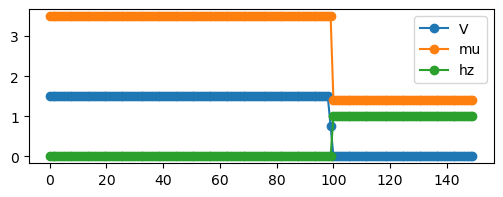

In [112]:
widthS = 100
widthF = 50

X, Y = widthS+widthF, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 3.5 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:] = muF

h0 = 1 * t
h = np.zeros_like(mu)
h[widthS:] = h0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2
U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [113]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1+0.1, 0.1-0.1, 0.1+0.1j, 0.1-0.1j],
                hz=h, F0_init=0.1)

In [115]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 4.705223774933294e-06
Relative error: 0.0007922524284792344
Average old: (-0.07831082445158367+0j)
Average: (-0.07831088654549782+0j)
F_xplus:
Absolute error: 0.00025926087751160795
Relative error: 0.0027927127881332454
Average old: (0.07800133520535375+0j)
Average: (0.07798410128255667+0j)
F_xmin:
Absolute error: 0.00026190493154276326
Relative error: 0.002575431924944399
Average old: (0.07762985771202109+0j)
Average: (0.07764720239175939+0j)
F_yplus:
Absolute error: 1.826193685380164e-05
Relative error: 0.0008273920145952736
Average old: (0.0784003947060637+2.360814044425223e-06j)
Average: (0.0784004969349642+1.1857473768815274e-06j)
F_ymin:
Absolute error: 1.826193685380164e-05
Relative error: 0.0008273920145952736
Average old: (0.0784003947060637-2.360814044425223e-06j)
Average: (0.0784004969349642-1.1857473768815274e-06j)
Fuu_xplus:
Absolute error: 9.675487897420535e-17
Relative error: 9.675455968554902e-05
Average old: (5.147036920373159e-19+0j)
Average: (-2.1

In [118]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.001, hz/t=1


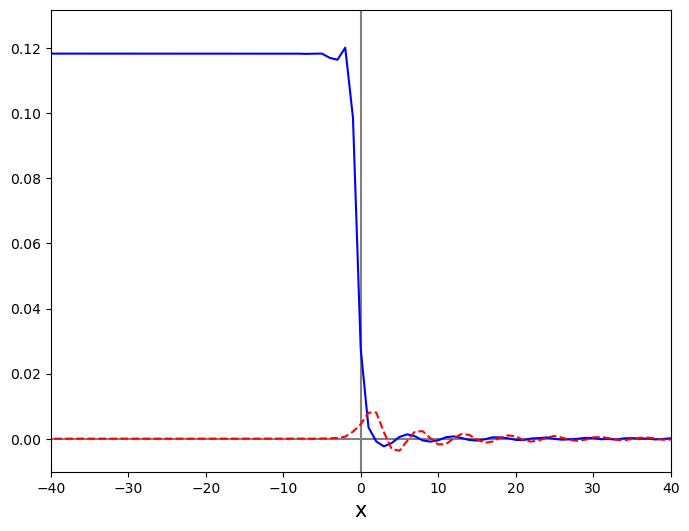

In [156]:
x = np.arange(-widthS, widthF) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')

axs.plot(x, np.real(F_swave), label=r"$\uparrow\downarrow -\downarrow\uparrow$", color='blue')
axs.plot(x, np.real(F.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_xlim(-40, 40)
plt.show()

C:\Users\emoeu\AppData\Local\Temp\ipykernel_26976\2704608143.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


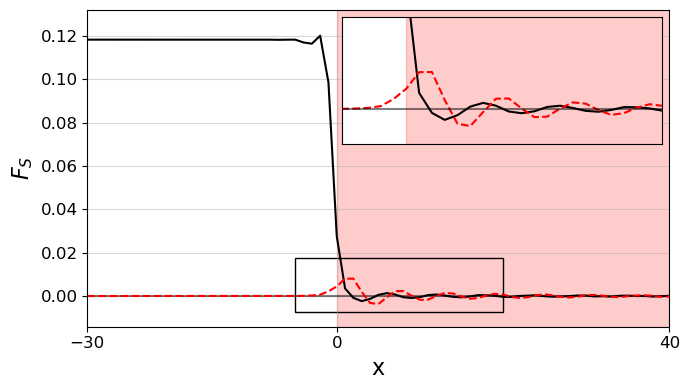

In [186]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

plt.figure(figsize=(7, 4))
ax = plt.gca()

x = np.arange(-widthS, widthF) + 1
# Main plot
plt.axhline(0, color='black', alpha=0.5)
ln_nm, = ax.plot(x,np.real(F_swave), color='black')
ln_fm, = ax.plot(x,np.real(F.px), color='red', linestyle='--')

# ax.axvspan(x[0], 0, color='blue', alpha=0.2)
ax.axvspan(0, x[-1], color='red', alpha=0.2)

square = Rectangle((-5, -0.0075), 25, 0.025, edgecolor='black', facecolor='none', linewidth=1)
ax.add_patch(square)

ax.set_xticks([-30,0,40])
ax.grid(True, alpha=0.5)
ax.set_xlabel(r"x", fontsize=16)
ax.set_ylabel(r"$F_{S}$", fontsize=16)
ax.tick_params(labelsize=12)
ax.set_xlim(-30, 40)

axins = inset_axes(ax, width="55%", height="40%", loc="upper right")

axins.axvspan(0, widthF, color='red', alpha=0.2)
axins.plot(x,np.real(F_swave), color='black')
axins.plot(x,np.real(F.px), color='red', linestyle='--')

axins.set_xlim(-5, 20)
axins.set_ylim(-0.0075, 0.02)
axins.axhline(0, color='black', alpha=0.5)
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/corr.svg', bbox_inches='tight')


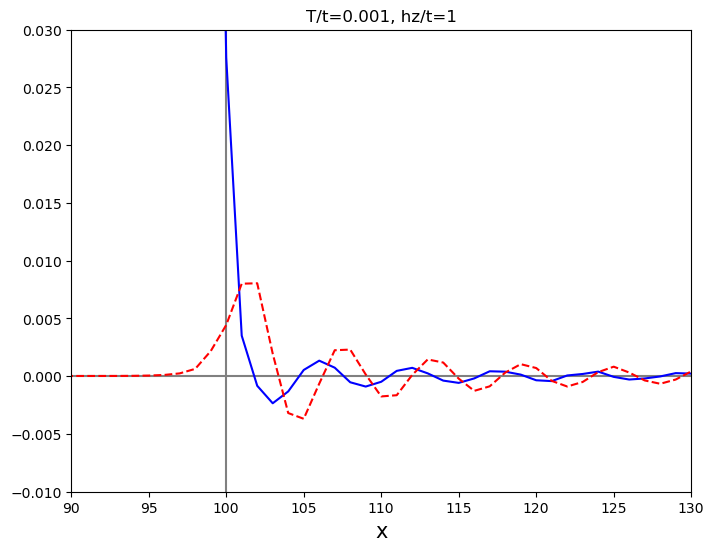

In [150]:
x = np.arange(1, widthS + widthF + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(100, color='gray')

axs.plot(x, np.real(F_swave), label=r"$\uparrow\downarrow -\downarrow\uparrow$", color='blue')
axs.plot(x, np.real(F.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_ylim(-0.01, 0.03)
axs.set_xlim(90, 130)
plt.show()